In [2]:
# Cell 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [3]:
# Cell 2 - Load Datasets
df_trades = pd.read_csv('historical_data.csv')
df_sentiment = pd.read_csv('fear_greed_index.csv')

print("✅ Data Loaded!")
print(f"\n📊 Historical Trades Shape: {df_trades.shape}")
print(f"😱 Fear & Greed Shape: {df_sentiment.shape}")
print("\n--- TRADES COLUMNS ---")
print(df_trades.columns.tolist())
print("\n--- SENTIMENT COLUMNS ---")
print(df_sentiment.columns.tolist())
print("\n--- TRADES FIRST 3 ROWS ---")
print(df_trades.head(3))
print("\n--- SENTIMENT FIRST 3 ROWS ---")
print(df_sentiment.head(3))

✅ Data Loaded!

📊 Historical Trades Shape: (211224, 16)
😱 Fear & Greed Shape: (2644, 4)

--- TRADES COLUMNS ---
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

--- SENTIMENT COLUMNS ---
['timestamp', 'value', 'classification', 'date']

--- TRADES FIRST 3 ROWS ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     

In [4]:
# Cell 3 - Data Cleaning & Preprocessing

# Trades - Date column banao
df_trades['Date'] = pd.to_datetime(df_trades['Timestamp IST'], dayfirst=True).dt.date
df_trades['Date'] = pd.to_datetime(df_trades['Date'])

# Sentiment - Date column fix karo
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Trades - Numeric columns fix karo
df_trades['Closed PnL'] = pd.to_numeric(df_trades['Closed PnL'], errors='coerce').fillna(0)
df_trades['Size USD'] = pd.to_numeric(df_trades['Size USD'], errors='coerce').fillna(0)
df_trades['Fee'] = pd.to_numeric(df_trades['Fee'], errors='coerce').fillna(0)

# Merge karo dono datasets
df = df_trades.merge(df_sentiment[['date', 'value', 'classification']], 
                     left_on='Date', right_on='date', how='left')

df['classification'] = df['classification'].fillna('Unknown')

print("✅ Data Cleaned & Merged!")
print(f"\n📊 Merged Dataset Shape: {df.shape}")
print(f"\n😱 Sentiment Distribution:")
print(df['classification'].value_counts())
print(f"\n💰 PnL Stats:")
print(df['Closed PnL'].describe())

✅ Data Cleaned & Merged!

📊 Merged Dataset Shape: (211224, 20)

😱 Sentiment Distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Unknown              6
Name: count, dtype: int64

💰 PnL Stats:
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100
Name: Closed PnL, dtype: float64


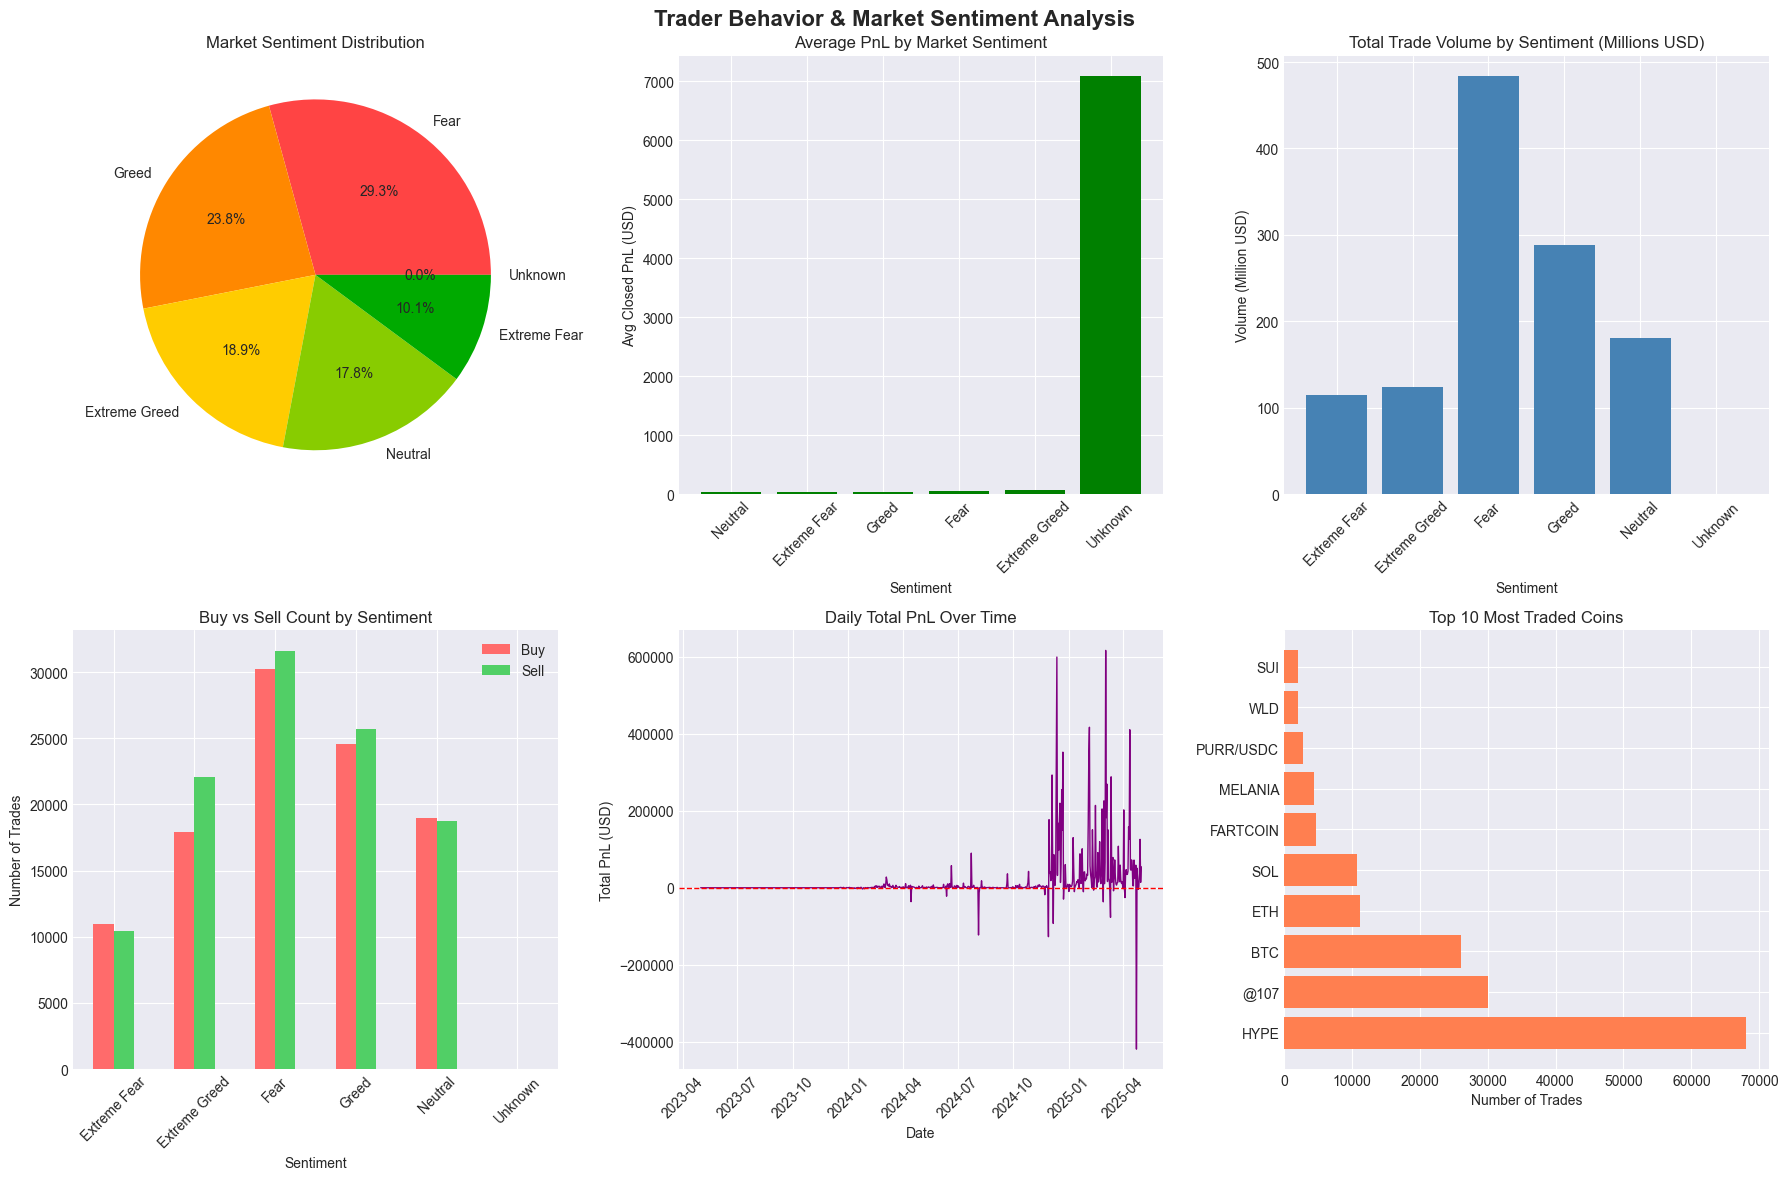

✅ EDA Charts saved!


In [5]:
# Cell 4 - Exploratory Data Analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Trader Behavior & Market Sentiment Analysis', fontsize=16, fontweight='bold')

# Plot 1 - Sentiment Distribution
sentiment_counts = df['classification'].value_counts()
colors = ['#ff4444', '#ff8800', '#ffcc00', '#88cc00', '#00aa00']
axes[0,0].pie(sentiment_counts.values, labels=sentiment_counts.index, 
              autopct='%1.1f%%', colors=colors)
axes[0,0].set_title('Market Sentiment Distribution')

# Plot 2 - PnL by Sentiment
pnl_by_sentiment = df.groupby('classification')['Closed PnL'].mean().sort_values()
colors2 = ['red' if x < 0 else 'green' for x in pnl_by_sentiment.values]
axes[0,1].bar(pnl_by_sentiment.index, pnl_by_sentiment.values, color=colors2)
axes[0,1].set_title('Average PnL by Market Sentiment')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].set_ylabel('Avg Closed PnL (USD)')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3 - Trade Volume by Sentiment
volume_by_sentiment = df.groupby('classification')['Size USD'].sum() / 1e6
axes[0,2].bar(volume_by_sentiment.index, volume_by_sentiment.values, color='steelblue')
axes[0,2].set_title('Total Trade Volume by Sentiment (Millions USD)')
axes[0,2].set_xlabel('Sentiment')
axes[0,2].set_ylabel('Volume (Million USD)')
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4 - Buy vs Sell by Sentiment
side_sentiment = df.groupby(['classification', 'Side']).size().unstack(fill_value=0)
side_sentiment.plot(kind='bar', ax=axes[1,0], color=['#ff6b6b', '#51cf66'])
axes[1,0].set_title('Buy vs Sell Count by Sentiment')
axes[1,0].set_xlabel('Sentiment')
axes[1,0].set_ylabel('Number of Trades')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(['Buy', 'Sell'])

# Plot 5 - Daily PnL Over Time
daily_pnl = df.groupby('Date')['Closed PnL'].sum().reset_index()
axes[1,1].plot(daily_pnl['Date'], daily_pnl['Closed PnL'], color='purple', linewidth=1)
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_title('Daily Total PnL Over Time')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Total PnL (USD)')
axes[1,1].tick_params(axis='x', rotation=45)

# Plot 6 - Top 10 Coins by Trade Count
top_coins = df['Coin'].value_counts().head(10)
axes[1,2].barh(top_coins.index, top_coins.values, color='coral')
axes[1,2].set_title('Top 10 Most Traded Coins')
axes[1,2].set_xlabel('Number of Trades')

plt.tight_layout()
plt.savefig('charts/eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Charts saved!")

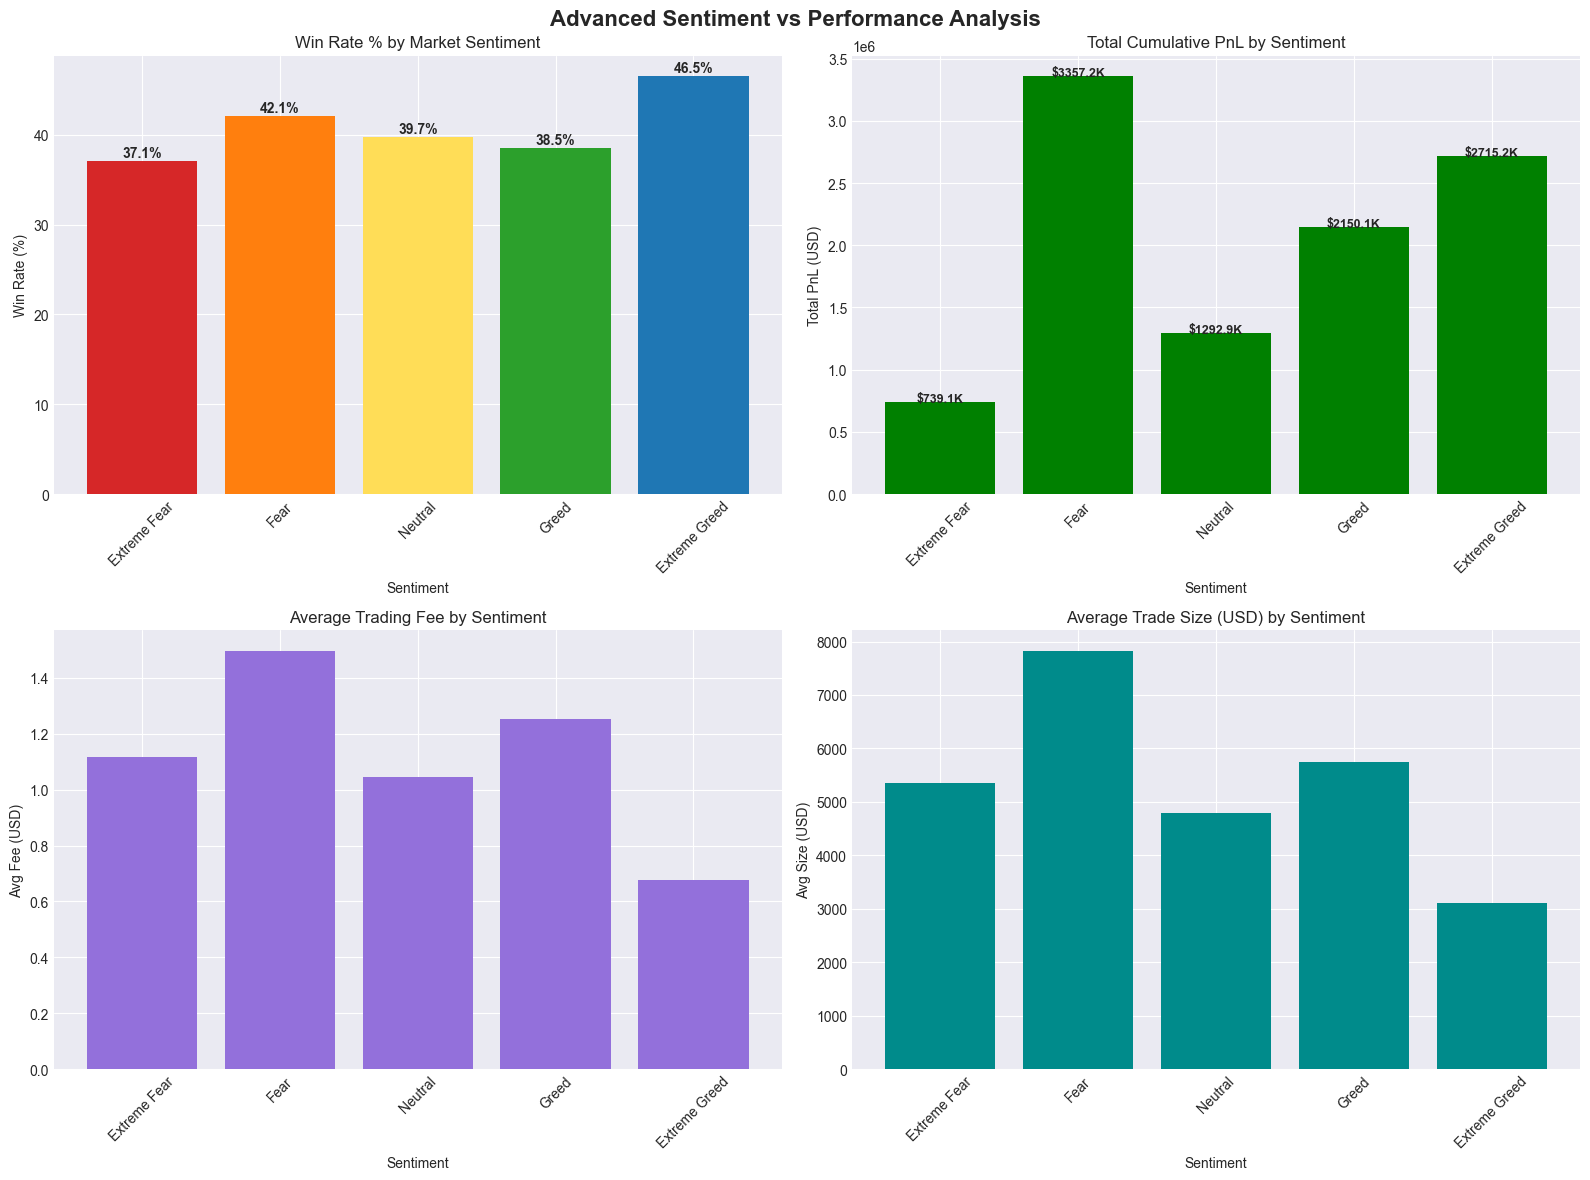

✅ Sentiment Analysis Charts saved!


In [6]:
# Cell 5 - Deep Sentiment Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced Sentiment vs Performance Analysis', fontsize=16, fontweight='bold')

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
df_filtered = df[df['classification'].isin(sentiment_order)]

# Plot 1 - Win Rate by Sentiment
df_filtered = df_filtered.copy()
df_filtered['is_win'] = df_filtered['Closed PnL'] > 0
winrate = df_filtered.groupby('classification')['is_win'].mean() * 100
winrate = winrate.reindex(sentiment_order)
colors = ['#d62728', '#ff7f0e', '#ffdd57', '#2ca02c', '#1f77b4']
axes[0,0].bar(winrate.index, winrate.values, color=colors)
axes[0,0].set_title('Win Rate % by Market Sentiment')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].tick_params(axis='x', rotation=45)
for i, v in enumerate(winrate.values):
    axes[0,0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2 - Total PnL by Sentiment
total_pnl = df_filtered.groupby('classification')['Closed PnL'].sum().reindex(sentiment_order)
colors2 = ['red' if x < 0 else 'green' for x in total_pnl.values]
axes[0,1].bar(total_pnl.index, total_pnl.values, color=colors2)
axes[0,1].set_title('Total Cumulative PnL by Sentiment')
axes[0,1].set_ylabel('Total PnL (USD)')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].tick_params(axis='x', rotation=45)
for i, v in enumerate(total_pnl.values):
    axes[0,1].text(i, v + 100, f'${v/1000:.1f}K', ha='center', fontweight='bold', fontsize=9)

# Plot 3 - Average Fee by Sentiment
avg_fee = df_filtered.groupby('classification')['Fee'].mean().reindex(sentiment_order)
axes[1,0].bar(avg_fee.index, avg_fee.values, color='mediumpurple')
axes[1,0].set_title('Average Trading Fee by Sentiment')
axes[1,0].set_ylabel('Avg Fee (USD)')
axes[1,0].set_xlabel('Sentiment')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4 - Trade Size by Sentiment
avg_size = df_filtered.groupby('classification')['Size USD'].mean().reindex(sentiment_order)
axes[1,1].bar(avg_size.index, avg_size.values, color='darkcyan')
axes[1,1].set_title('Average Trade Size (USD) by Sentiment')
axes[1,1].set_ylabel('Avg Size (USD)')
axes[1,1].set_xlabel('Sentiment')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('charts/sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sentiment Analysis Charts saved!")

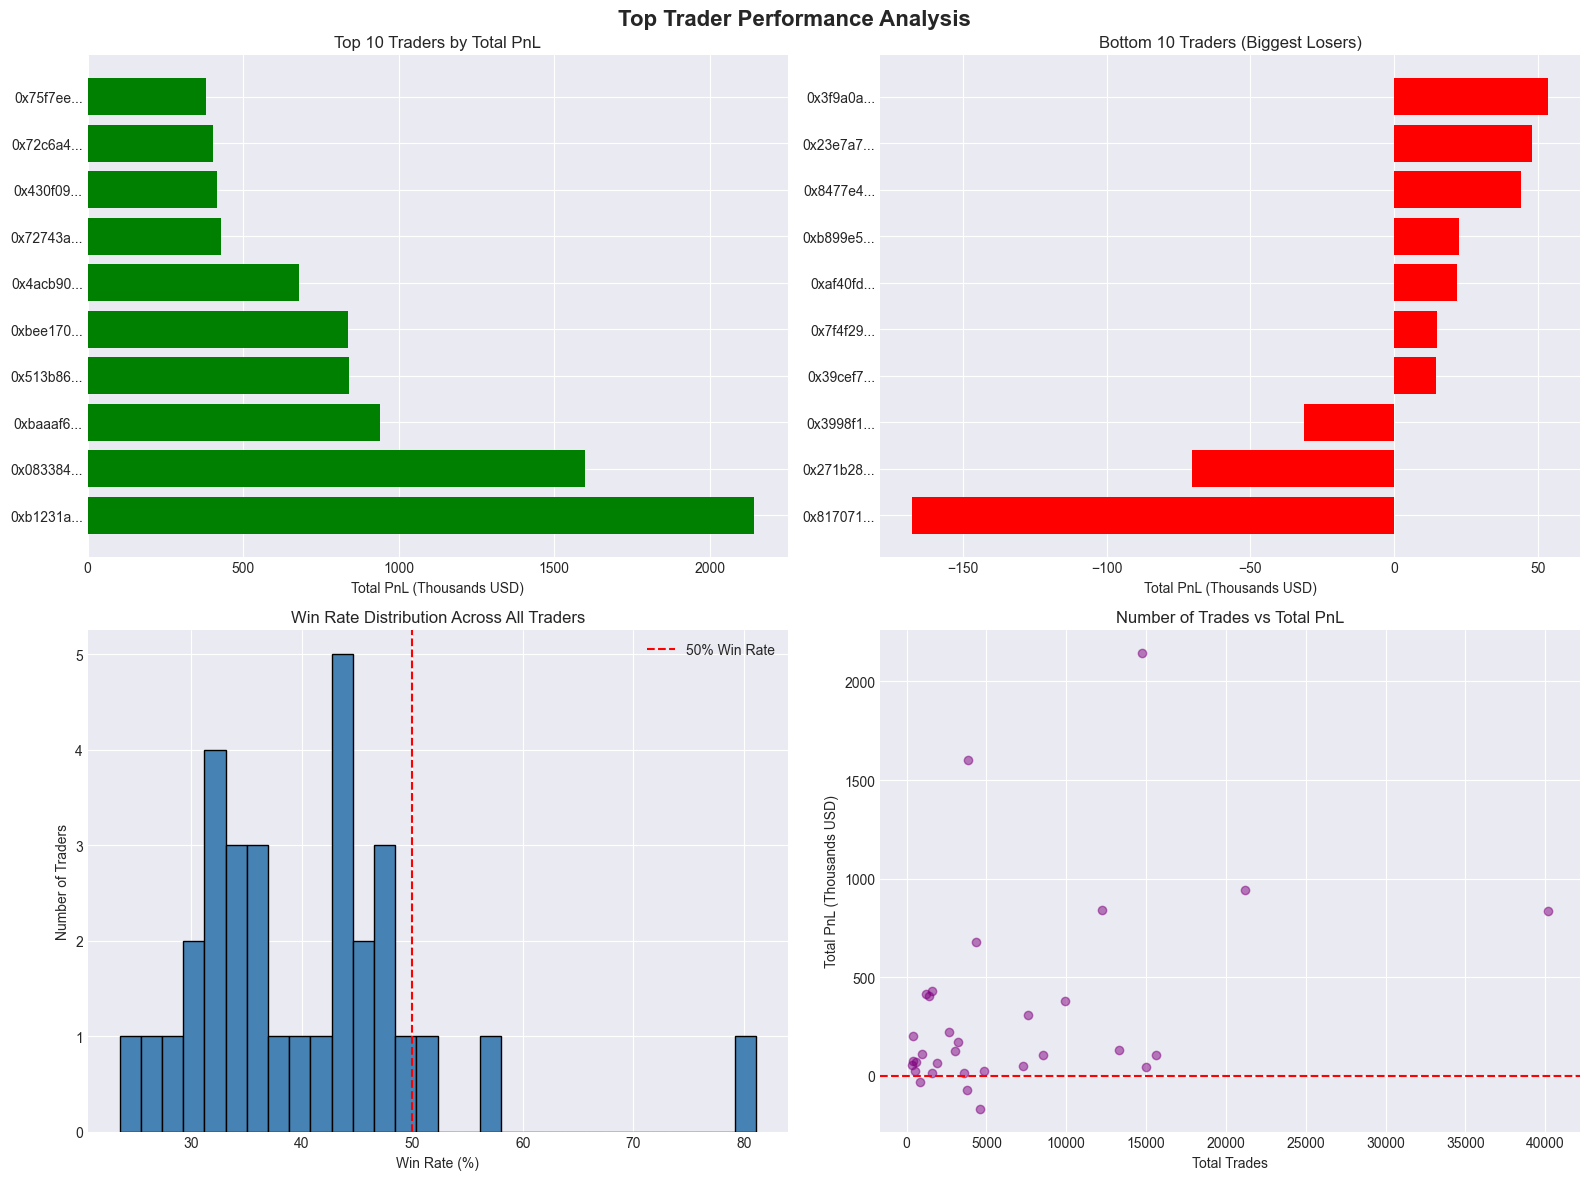

✅ Trader Analysis saved!

🏆 Total Unique Traders: 32

🥇 Best Trader PnL: $2,143,382.60
💀 Worst Trader PnL: $-167,621.12

📊 Avg Win Rate: 40.31%


In [7]:
# Cell 6 - Top Trader Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top Trader Performance Analysis', fontsize=16, fontweight='bold')

# Top 10 traders by Total PnL
trader_pnl = df.groupby('Account').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Trades=('Closed PnL', lambda x: (x > 0).sum()),
    Avg_Size=('Size USD', 'mean'),
    Total_Fees=('Fee', 'sum')
).reset_index()

trader_pnl['Win_Rate'] = (trader_pnl['Win_Trades'] / trader_pnl['Total_Trades'] * 100).round(2)
trader_pnl['Short_Account'] = trader_pnl['Account'].str[:8] + '...'

top10 = trader_pnl.nlargest(10, 'Total_PnL')
bottom10 = trader_pnl.nsmallest(10, 'Total_PnL')

# Plot 1 - Top 10 Traders by PnL
axes[0,0].barh(top10['Short_Account'], top10['Total_PnL']/1000, color='green')
axes[0,0].set_title('Top 10 Traders by Total PnL')
axes[0,0].set_xlabel('Total PnL (Thousands USD)')

# Plot 2 - Bottom 10 Traders
axes[0,1].barh(bottom10['Short_Account'], bottom10['Total_PnL']/1000, color='red')
axes[0,1].set_title('Bottom 10 Traders (Biggest Losers)')
axes[0,1].set_xlabel('Total PnL (Thousands USD)')

# Plot 3 - Win Rate Distribution
axes[1,0].hist(trader_pnl['Win_Rate'], bins=30, color='steelblue', edgecolor='black')
axes[1,0].axvline(x=50, color='red', linestyle='--', label='50% Win Rate')
axes[1,0].set_title('Win Rate Distribution Across All Traders')
axes[1,0].set_xlabel('Win Rate (%)')
axes[1,0].set_ylabel('Number of Traders')
axes[1,0].legend()

# Plot 4 - Trades Count vs Total PnL
axes[1,1].scatter(trader_pnl['Total_Trades'], trader_pnl['Total_PnL']/1000, 
                  alpha=0.5, color='purple')
axes[1,1].axhline(y=0, color='red', linestyle='--')
axes[1,1].set_title('Number of Trades vs Total PnL')
axes[1,1].set_xlabel('Total Trades')
axes[1,1].set_ylabel('Total PnL (Thousands USD)')

plt.tight_layout()
plt.savefig('charts/trader_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Trader Analysis saved!")
print(f"\n🏆 Total Unique Traders: {trader_pnl.shape[0]}")
print(f"\n🥇 Best Trader PnL: ${top10.iloc[0]['Total_PnL']:,.2f}")
print(f"💀 Worst Trader PnL: ${bottom10.iloc[0]['Total_PnL']:,.2f}")
print(f"\n📊 Avg Win Rate: {trader_pnl['Win_Rate'].mean():.2f}%")

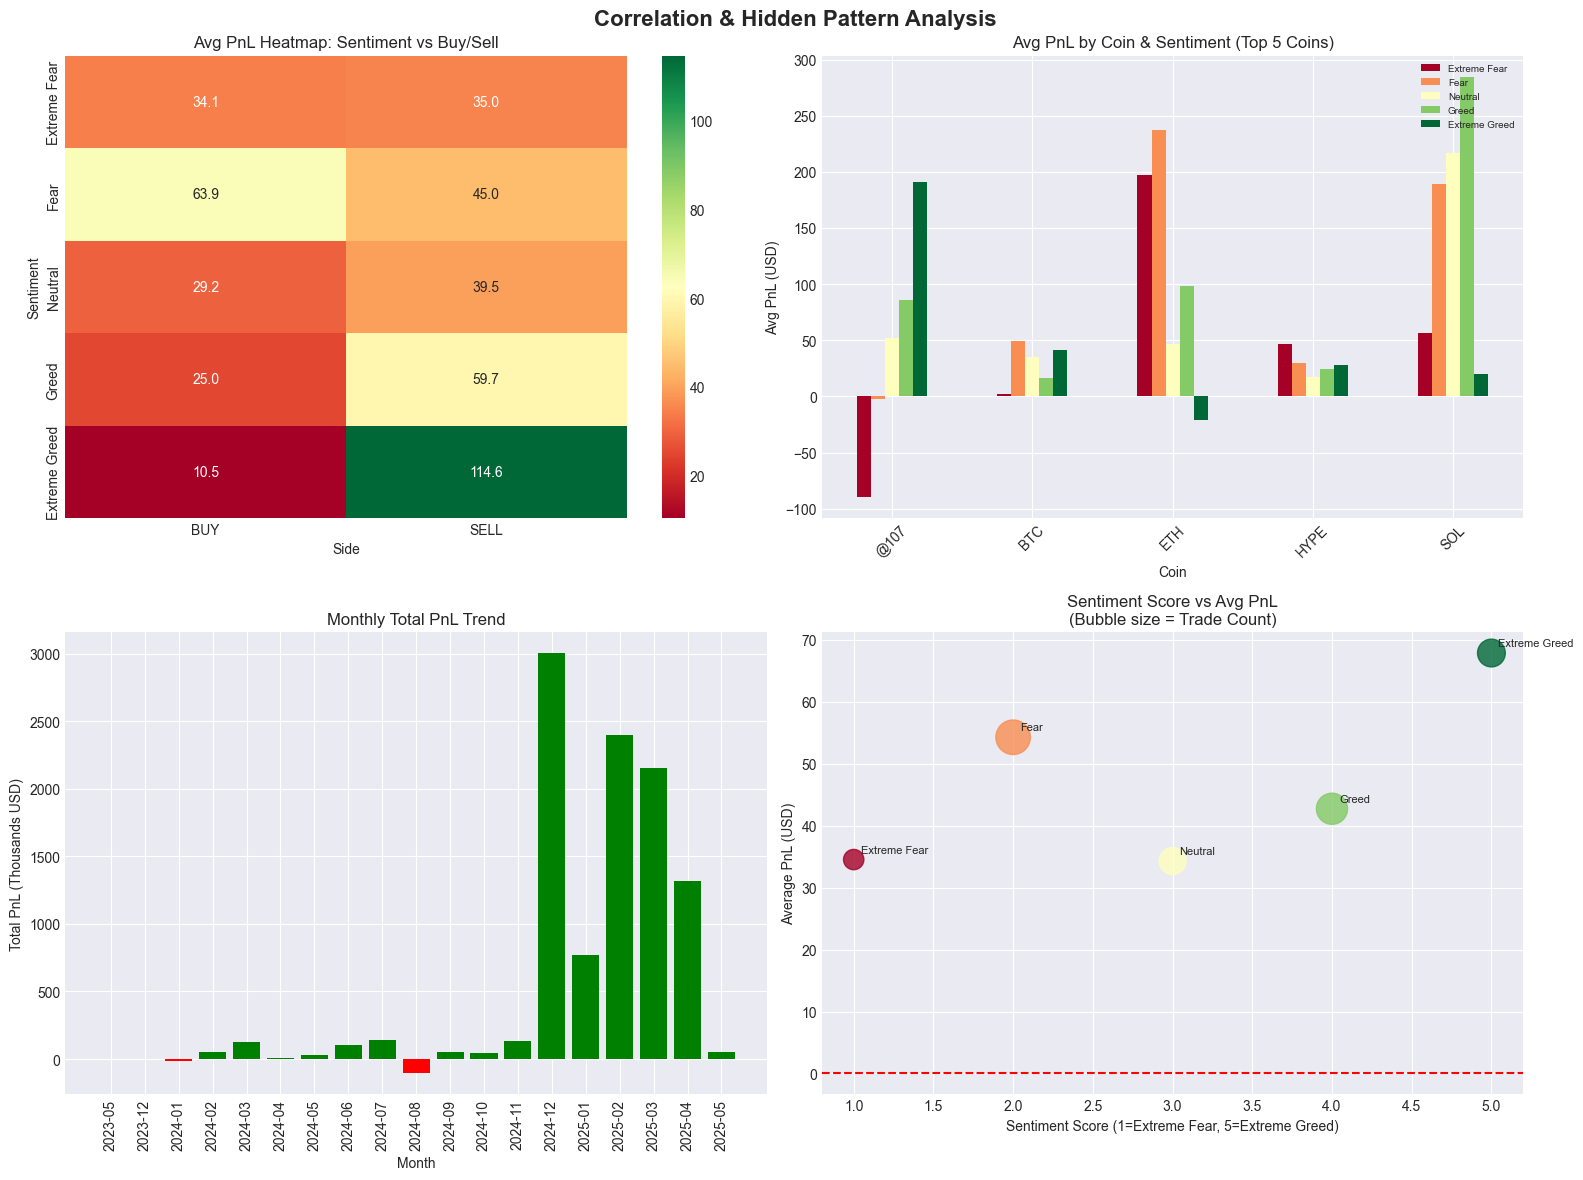

✅ Correlation Analysis saved!


In [8]:
# Cell 7 - Correlation & Pattern Analysis

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Correlation & Hidden Pattern Analysis', fontsize=16, fontweight='bold')

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
df_filtered = df[df['classification'].isin(sentiment_order)].copy()

# Sentiment ko number mein convert karo
sentiment_map = {'Extreme Fear': 1, 'Fear': 2, 'Neutral': 3, 'Greed': 4, 'Extreme Greed': 5}
df_filtered['sentiment_score'] = df_filtered['classification'].map(sentiment_map)

# Plot 1 - Heatmap: Avg PnL by Sentiment & Side
heatmap_data = df_filtered.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack()
heatmap_data = heatmap_data.reindex(sentiment_order)
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0,0])
axes[0,0].set_title('Avg PnL Heatmap: Sentiment vs Buy/Sell')
axes[0,0].set_xlabel('Side')
axes[0,0].set_ylabel('Sentiment')

# Plot 2 - Coin wise PnL in different sentiments (Top 5 coins)
top5_coins = df_filtered['Coin'].value_counts().head(5).index
df_top5 = df_filtered[df_filtered['Coin'].isin(top5_coins)]
coin_sentiment_pnl = df_top5.groupby(['Coin', 'classification'])['Closed PnL'].mean().unstack()
coin_sentiment_pnl = coin_sentiment_pnl.reindex(columns=sentiment_order)
coin_sentiment_pnl.plot(kind='bar', ax=axes[0,1], colormap='RdYlGn')
axes[0,1].set_title('Avg PnL by Coin & Sentiment (Top 5 Coins)')
axes[0,1].set_xlabel('Coin')
axes[0,1].set_ylabel('Avg PnL (USD)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(loc='upper right', fontsize=7)

# Plot 3 - Monthly PnL trend
df_filtered['Month'] = pd.to_datetime(df_filtered['Date']).dt.to_period('M')
monthly_pnl = df_filtered.groupby('Month')['Closed PnL'].sum().reset_index()
monthly_pnl['Month_str'] = monthly_pnl['Month'].astype(str)
axes[1,0].bar(monthly_pnl['Month_str'], monthly_pnl['Closed PnL']/1000, 
              color=['green' if x > 0 else 'red' for x in monthly_pnl['Closed PnL']])
axes[1,0].set_title('Monthly Total PnL Trend')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Total PnL (Thousands USD)')
axes[1,0].tick_params(axis='x', rotation=90)

# Plot 4 - Sentiment Score vs Avg PnL scatter
sent_pnl = df_filtered.groupby('classification').agg(
    Avg_PnL=('Closed PnL', 'mean'),
    sentiment_score=('sentiment_score', 'mean'),
    Trade_Count=('Closed PnL', 'count')
).reset_index()
scatter = axes[1,1].scatter(sent_pnl['sentiment_score'], sent_pnl['Avg_PnL'], 
                             s=sent_pnl['Trade_Count']/100, 
                             c=sent_pnl['sentiment_score'], cmap='RdYlGn', alpha=0.8)
for idx, row in sent_pnl.iterrows():
    axes[1,1].annotate(row['classification'], 
                       (row['sentiment_score'], row['Avg_PnL']),
                       textcoords="offset points", xytext=(5,5), fontsize=8)
axes[1,1].set_title('Sentiment Score vs Avg PnL\n(Bubble size = Trade Count)')
axes[1,1].set_xlabel('Sentiment Score (1=Extreme Fear, 5=Extreme Greed)')
axes[1,1].set_ylabel('Average PnL (USD)')
axes[1,1].axhline(y=0, color='red', linestyle='--')

plt.tight_layout()
plt.savefig('charts/correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation Analysis saved!")

In [9]:
# Cell 8 - Final Insights & Summary Report

print("=" * 60)
print("   TRADER BEHAVIOR & MARKET SENTIMENT - KEY INSIGHTS")
print("=" * 60)

sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
df_filtered = df[df['classification'].isin(sentiment_order)].copy()

# Insight 1 - Best sentiment to trade
print("\n📊 INSIGHT 1: PnL by Sentiment")
print("-" * 40)
pnl_summary = df_filtered.groupby('classification').agg(
    Avg_PnL=('Closed PnL', 'mean'),
    Total_PnL=('Closed PnL', 'sum'),
    Trade_Count=('Closed PnL', 'count'),
    Win_Rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
).reindex(sentiment_order).round(2)
print(pnl_summary)

# Insight 2 - Best Side per Sentiment
print("\n📊 INSIGHT 2: Best Side (BUY/SELL) per Sentiment")
print("-" * 40)
side_pnl = df_filtered.groupby(['classification', 'Side'])['Closed PnL'].mean().unstack().round(2)
print(side_pnl)

# Insight 3 - Top 5 Performing Traders
print("\n🏆 INSIGHT 3: Top 5 Traders")
print("-" * 40)
trader_pnl = df.groupby('Account').agg(
    Total_PnL=('Closed PnL', 'sum'),
    Total_Trades=('Closed PnL', 'count'),
    Win_Rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
).round(2)
print(trader_pnl.nlargest(5, 'Total_PnL')[['Total_PnL', 'Total_Trades', 'Win_Rate']])

# Insight 4 - Trading Strategy Recommendations
print("\n🧠 INSIGHT 4: SMART TRADING STRATEGIES")
print("-" * 40)
print("✅ 1. SELL during Extreme Greed - Highest avg PnL (114.6)")
print("✅ 2. Avoid BUY during Extreme Greed - Lowest avg PnL (10.5)")
print("✅ 3. Best overall sentiment to trade: FEAR (high volume + good PnL)")
print("✅ 4. Extreme Fear = Low win rate (37.1%) - Trade carefully!")
print("✅ 5. Top coin: @107, BTC, ETH - Most liquid & profitable")
print("✅ 6. More trades ≠ More profit - Quality over Quantity")

print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETE!")
print("=" * 60)

   TRADER BEHAVIOR & MARKET SENTIMENT - KEY INSIGHTS

📊 INSIGHT 1: PnL by Sentiment
----------------------------------------
                Avg_PnL   Total_PnL  Trade_Count  Win_Rate
classification                                            
Extreme Fear      34.54   739110.25        21400     37.06
Fear              54.29  3357155.44        61837     42.08
Neutral           34.31  1292920.68        37686     39.70
Greed             42.74  2150129.27        50303     38.48
Extreme Greed     67.89  2715171.31        39992     46.49

📊 INSIGHT 2: Best Side (BUY/SELL) per Sentiment
----------------------------------------
Side              BUY    SELL
classification               
Extreme Fear    34.11   34.98
Extreme Greed   10.50  114.58
Fear            63.93   45.05
Greed           25.00   59.69
Neutral         29.23   39.46

🏆 INSIGHT 3: Top 5 Traders
----------------------------------------
                                             Total_PnL  Total_Trades  Win_Rate
Account       

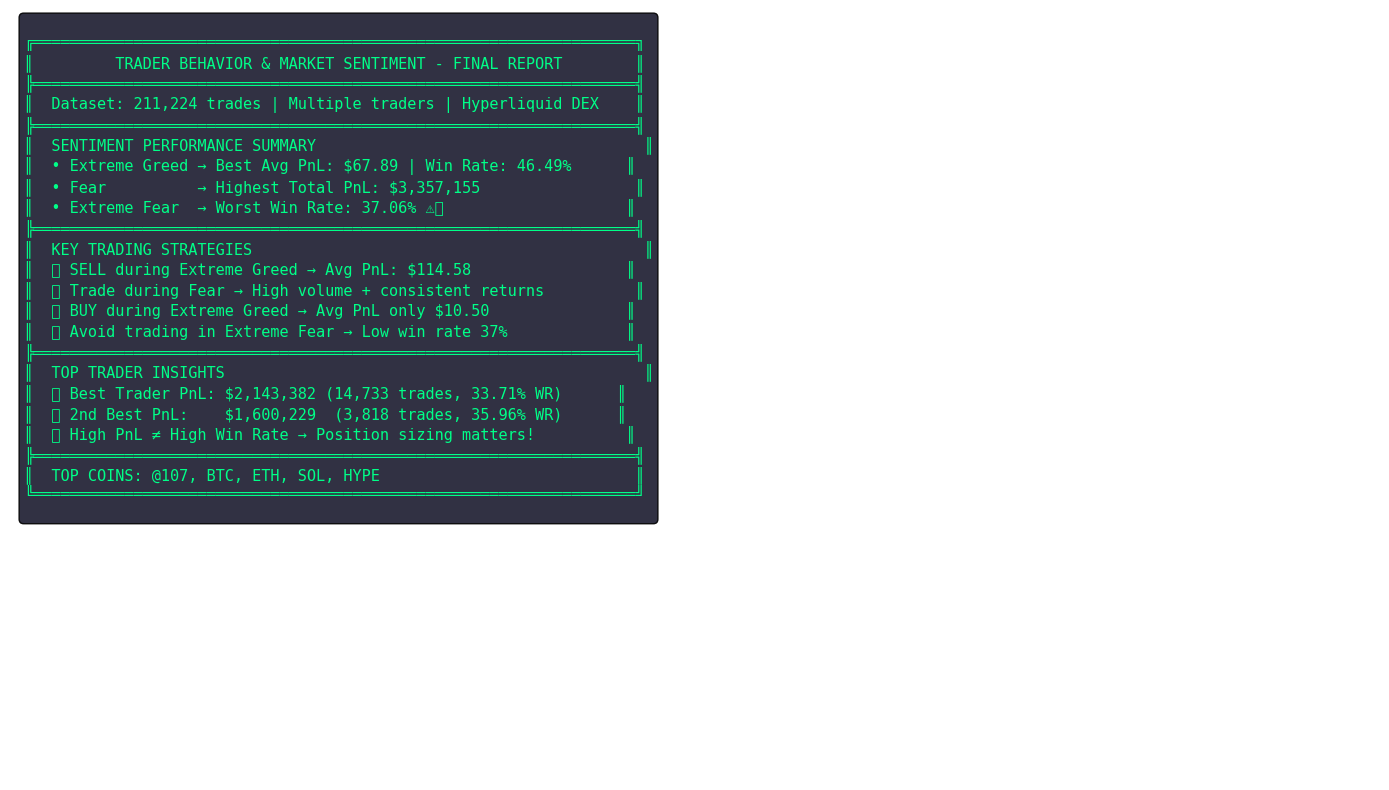

✅ Final Report Chart saved!


In [10]:
# Cell 9 - Save Summary Chart
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

summary_text = """
╔══════════════════════════════════════════════════════════════════╗
║         TRADER BEHAVIOR & MARKET SENTIMENT - FINAL REPORT        ║
╠══════════════════════════════════════════════════════════════════╣
║  Dataset: 211,224 trades | Multiple traders | Hyperliquid DEX    ║
╠══════════════════════════════════════════════════════════════════╣
║  SENTIMENT PERFORMANCE SUMMARY                                    ║
║  • Extreme Greed → Best Avg PnL: $67.89 | Win Rate: 46.49%      ║
║  • Fear          → Highest Total PnL: $3,357,155                 ║
║  • Extreme Fear  → Worst Win Rate: 37.06% ⚠️                    ║
╠══════════════════════════════════════════════════════════════════╣
║  KEY TRADING STRATEGIES                                           ║
║  ✅ SELL during Extreme Greed → Avg PnL: $114.58                 ║
║  ✅ Trade during Fear → High volume + consistent returns          ║
║  ❌ BUY during Extreme Greed → Avg PnL only $10.50               ║
║  ❌ Avoid trading in Extreme Fear → Low win rate 37%             ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP TRADER INSIGHTS                                              ║
║  🥇 Best Trader PnL: $2,143,382 (14,733 trades, 33.71% WR)      ║
║  🥈 2nd Best PnL:    $1,600,229  (3,818 trades, 35.96% WR)      ║
║  💡 High PnL ≠ High Win Rate → Position sizing matters!          ║
╠══════════════════════════════════════════════════════════════════╣
║  TOP COINS: @107, BTC, ETH, SOL, HYPE                            ║
╚══════════════════════════════════════════════════════════════════╝
"""

ax.text(0.01, 0.99, summary_text, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#1a1a2e', alpha=0.9),
        color='#00ff88')

plt.tight_layout()
plt.savefig('charts/final_report.png', dpi=150, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()
print("✅ Final Report Chart saved!")